### **[Graph Theory: Garbage Truck Route Planning](https://medium.com/@davidlfliang/6c2df3770bcb)**

> *The Closed Tour Problem: Route Optimization*

In [1]:
import sys

import numpy as np

import warnings
warnings.filterwarnings('ignore')

from itertools import combinations, permutations

import networkx as nx
import matplotlib.pyplot as plt

IN_COLAB = 'google.colab' in sys.modules

%autosave 15

Autosaving every 15 seconds


In [2]:
# Final Demo Version - Simple DFS
graph = {
  1: [2, 5],
  2: [1, 3],
  3: [2, 4],
  4: [3, 5],
  5: [4, 1]
}

def find_eulerian_cycle(graph, start, path=None, used_edges=None):
  if path is None:
    path = [start]
  if used_edges is None:
    used_edges = set()

  current = path[-1]

  # If all edges are used and we're back at start, we found the cycle
  total_edges = sum(len(neighbors) for neighbors in graph.values()) // 2
  if len(used_edges) == total_edges:
    if path[0] == path[-1]:
      return path
    return None

  # Try each neighbor
  for neighbor in graph[current]:
    edge = tuple(sorted((current, neighbor)))

    # If this edge hasn't been used yet
    if edge not in used_edges:
      # Use this edge
      used_edges.add(edge)
      path.append(neighbor)

      # Recursively explore
      result = find_eulerian_cycle(graph, start, path, used_edges)
      if result:
        return result

      # Backtrack
      path.pop()
      used_edges.remove(edge)

  return None

# Check if Eulerian cycle exists (all vertices must have even degree)
degrees = {node: len(neighbors) for node, neighbors in graph.items()}
all_even = all(deg % 2 == 0 for deg in degrees.values())

print("Graph degrees:", degrees)
print("All vertices have even degree:", all_even)

if all_even:
  print("\nEulerian cycle exists! Searching for path...")
  cycle = find_eulerian_cycle(graph, 1)

  if cycle:
    print(f"Eulerian cycle found: {' -> '.join(map(str, cycle))}")

    # Verify all edges are used exactly once
    used_edges = set()
    for i in range(len(cycle)-1):
      edge = tuple(sorted((cycle[i], cycle[i+1])))
      used_edges.add(edge)

    total_edges = sum(len(neighbors) for neighbors in graph.values()) // 2
    print(f"\nVerification:")
    print(f"Path length: {len(cycle)} nodes")
    print(f"Used {len(used_edges)} edges out of {total_edges} total edges")
    print(f"Edges used: {used_edges}")

    if len(used_edges) == total_edges:
      print("✓ All edges used exactly once!")
    else:
      print("✗ Some edges missed")
  else:
    print("No Eulerian cycle found")
else:
  print("No Eulerian cycle exists (not all vertices have even degree)")

Graph degrees: {1: 2, 2: 2, 3: 2, 4: 2, 5: 2}
All vertices have even degree: True

Eulerian cycle exists! Searching for path...
Eulerian cycle found: 1 -> 2 -> 3 -> 4 -> 5 -> 1

Verification:
Path length: 6 nodes
Used 5 edges out of 5 total edges
Edges used: {(1, 2), (3, 4), (1, 5), (2, 3), (4, 5)}
✓ All edges used exactly once!


Graph degrees: {1: 2, 2: 2, 3: 2, 4: 2, 5: 2}
All vertices have even degree: True

Eulerian cycle exists! Searching for path...
Eulerian cycle found: 1 -> 2 -> 3 -> 4 -> 5 -> 1

Verification:
Path length: 6 nodes
Used 5 edges out of 5 total edges
Edges used: {(1, 2), (3, 4), (1, 5), (2, 3), (4, 5)}
✓ All edges used exactly once!


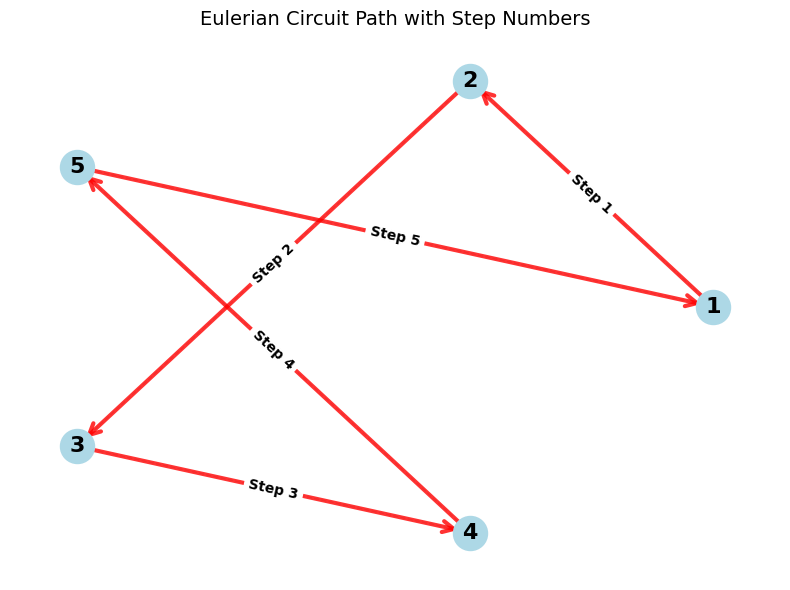


Path: 6 vertices, 5 edges
Graph has 5 total edges
Eulerian circuit edges in order: [(1, 2), (2, 3), (3, 4), (4, 5), (5, 1)]


In [3]:
graph = {
  1: [2, 5],
  2: [1, 3],
  3: [2, 4],
  4: [3, 5],
  5: [4, 1]
}

def find_eulerian_cycle(graph, start, path=None, used_edges=None):
  if path is None:
    path = [start]
  if used_edges is None:
    used_edges = set()

  current = path[-1]

  # If all edges are used and we're back at start, we found the cycle
  total_edges = sum(len(neighbors) for neighbors in graph.values()) // 2
  if len(used_edges) == total_edges:
    if path[0] == path[-1]:
      return path
    return None

  # Try each neighbor
  for neighbor in graph[current]:
    edge = tuple(sorted((current, neighbor)))

    # If this edge hasn't been used yet
    if edge not in used_edges:
      # Use this edge
      used_edges.add(edge)
      path.append(neighbor)

      # Recursively explore
      result = find_eulerian_cycle(graph, start, path, used_edges)
      if result:
        return result

      # Backtrack
      path.pop()
      used_edges.remove(edge)

  return None

# Check if Eulerian cycle exists (all vertices must have even degree)
degrees = {node: len(neighbors) for node, neighbors in graph.items()}
all_even = all(deg % 2 == 0 for deg in degrees.values())

print("Graph degrees:", degrees)
print("All vertices have even degree:", all_even)

if all_even:
  print("\nEulerian cycle exists! Searching for path...")
  cycle = find_eulerian_cycle(graph, 1)

  if cycle:
    print(f"Eulerian cycle found: {' -> '.join(map(str, cycle))}")

    # Verify all edges are used exactly once
    used_edges = set()
    for i in range(len(cycle)-1):
      edge = tuple(sorted((cycle[i], cycle[i+1])))
      used_edges.add(edge)

    total_edges = sum(len(neighbors) for neighbors in graph.values()) // 2
    print(f"\nVerification:")
    print(f"Path length: {len(cycle)} nodes")
    print(f"Used {len(used_edges)} edges out of {total_edges} total edges")
    print(f"Edges used: {used_edges}")

    if len(used_edges) == total_edges:
      print("✓ All edges used exactly once!")
    else:
      print("✗ Some edges missed")

    # Create graph for visualization
    G = nx.Graph()
    for node, neighbors in graph.items():
      for neighbor in neighbors:
        G.add_edge(node, neighbor)

    # Position nodes in a circle
    pos = nx.circular_layout(G)

    # Chart
    plt.figure(figsize=(8, 6))

    # Draw basic graph
    nx.draw_networkx_nodes(G, pos, node_size=600, node_color='lightblue')
    nx.draw_networkx_edges(G, pos, width=1, alpha=0.3, edge_color='gray', style='dashed')
    nx.draw_networkx_labels(G, pos, font_size=16, font_weight='bold')

    # Create directed graph for arrows
    G_dir = nx.DiGraph()
    circuit_edges = [(cycle[i], cycle[i+1]) for i in range(len(cycle)-1)]

    # Add directed edges for the circuit
    for u, v in circuit_edges:
      G_dir.add_edge(u, v)

    # Draw the Eulerian circuit with arrows
    nx.draw_networkx_edges(G_dir, pos, width=3, edge_color='red', alpha=0.8,
                          arrows=True, arrowsize=20, arrowstyle='->')

    # Add step numbers
    edge_labels = {}
    for i, (u, v) in enumerate(circuit_edges):
      edge_labels[(u, v)] = f"Step {i+1}"

    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=10, font_weight='bold')

    plt.title("Eulerian Circuit Path with Step Numbers", fontsize=14)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

    print(f"\nPath: {len(cycle)} vertices, {len(cycle)-1} edges")
    print(f"Graph has {sum(len(graph[v]) for v in graph)//2} total edges")
    print(f"Eulerian circuit edges in order: {circuit_edges}")

  else:
    print("No Eulerian cycle found")
else:
  print("No Eulerian cycle exists (not all vertices have even degree)")

In [4]:
# Final Demo Version - Simple DFS - 6 Nodes
graph = {
  1: [2, 6],
  2: [1, 3, 4, 5],
  3: [2, 4],
  4: [2, 3, 5, 6],
  5: [2, 4],
  6: [1, 4]
}

def find_eulerian_cycle(graph, start, path=None, used_edges=None):
  if path is None:
    path = [start]
  if used_edges is None:
    used_edges = set()

  current = path[-1]

  # If all edges are used and we're back at start, we found the cycle
  if len(used_edges) == sum(len(neighbors) for neighbors in graph.values()) // 2:
    if path[0] == path[-1]:
      return path
    return None

  # Try each neighbor
  for neighbor in graph[current]:
    edge = tuple(sorted((current, neighbor)))

    # If this edge hasn't been used yet
    if edge not in used_edges:
      # Use this edge
      used_edges.add(edge)
      path.append(neighbor)

      # Recursively explore
      result = find_eulerian_cycle(graph, start, path, used_edges)
      if result:
          return result

      # Backtrack
      path.pop()
      used_edges.remove(edge)

  return None

# Check if Eulerian cycle exists (all vertices must have even degree)
degrees = {node: len(neighbors) for node, neighbors in graph.items()}
all_even = all(deg % 2 == 0 for deg in degrees.values())

if all_even:
  print("Eulerian cycle exists (all vertices have even degree)")
  cycle = find_eulerian_cycle(graph, 1)
  if cycle:
    print(f"Eulerian cycle: {' -> '.join(map(str, cycle))}")

    # Verify all edges are used exactly once
    used_edges = set()
    for i in range(len(cycle)-1):
      edge = tuple(sorted((cycle[i], cycle[i+1])))
      used_edges.add(edge)

    total_edges = sum(len(neighbors) for neighbors in graph.values()) // 2
    print(f"Used {len(used_edges)} edges out of {total_edges} total edges")
    print("All edges used exactly once!" if len(used_edges) == total_edges else "Some edges missed")
else:
  print("No Eulerian cycle exists (not all vertices have even degree)")

Eulerian cycle exists (all vertices have even degree)
Eulerian cycle: 1 -> 2 -> 3 -> 4 -> 2 -> 5 -> 4 -> 6 -> 1
Used 8 edges out of 8 total edges
All edges used exactly once!


In [5]:
# Final Demo Version - 6 Nodes with DFS - The Visual
def find_eulerian_cycle(graph, start, path=None, used_edges=None):
  if path is None:
    path = [start]
  if used_edges is None:
    used_edges = set()

  current = path[-1]

  # If all edges are used and we're back at start, we found the cycle
  if len(used_edges) == sum(len(neighbors) for neighbors in graph.values()) // 2:
    if path[0] == path[-1]:
      return path
    return None

  # Try each neighbor
  for neighbor in graph[current]:
    edge = tuple(sorted((current, neighbor)))

    # If this edge hasn't been used yet
    if edge not in used_edges:
      # Use this edge
      used_edges.add(edge)
      path.append(neighbor)

      # Recursively explore
      result = find_eulerian_cycle(graph, start, path, used_edges)
      if result:
          return result

      # Backtrack
      path.pop()
      used_edges.remove(edge)

    return None

# Simple 6-node cycle
graph = {
  1: [2, 6],
  2: [1, 3, 4, 5],
  3: [2, 4],
  4: [2, 3, 5, 6],
  5: [2, 4],
  6: [1, 4]
}

print("Vertex degrees:")
for v in sorted(graph):
  print(f"Vertex {v}: degree {len(graph[v])}")

# Create NetworkX graph
G = nx.Graph()
for node, neighbors in graph.items():
  for neighbor in neighbors:
    G.add_edge(node, neighbor)

# Circular layout for cycle graph
pos = nx.circular_layout(G)

# Check if Eulerian cycle exists
degrees = {node: len(neighbors) for node, neighbors in graph.items()}
all_even = all(deg % 2 == 0 for deg in degrees.values())

if all_even:
  print("Eulerian cycle exists (all vertices have even degree)")

  # Find Eulerian cycle using DFS
  circuit = find_eulerian_cycle(graph, 1)

  if circuit:
      print("\nEulerian Circuit:", " → ".join(map(str, circuit)))

      # Eulerian circuit visualization with arrows and step numbers
      plt.figure(figsize=(8, 6))

      # Draw basic graph
      nx.draw_networkx_nodes(G, pos, node_size=600, node_color='lightblue')
      nx.draw_networkx_edges(G, pos, width=1, alpha=0.3, edge_color='gray', style='dashed')
      nx.draw_networkx_labels(G, pos, font_size=16, font_weight='bold')

      # Create directed graph for arrows
      G_dir = nx.DiGraph()
      circuit_edges = [(circuit[i], circuit[i+1]) for i in range(len(circuit)-1)]

      # Add directed edges for the circuit
      for u, v in circuit_edges:
          G_dir.add_edge(u, v)

      # Draw the Eulerian circuit with arrows
      nx.draw_networkx_edges(G_dir, pos, width=3, edge_color='red', alpha=0.8,
                            arrows=True, arrowsize=20, arrowstyle='->')

      # Add step numbers
      edge_labels = {}
      for i, (u, v) in enumerate(circuit_edges):
        edge_labels[(u, v)] = f"{i+1}"

      nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=10, font_weight='bold')

      plt.title("Eulerian Circuit Path with Step Numbers (DFS Solution)", fontsize=14)
      plt.axis('off')
      plt.tight_layout()
      plt.show()

      print(f"\nPath: {len(circuit)} vertices, {len(circuit)-1} edges")
      print(f"Graph has {sum(len(graph[v]) for v in graph)//2} total edges")

      # Verify all edges are used exactly once
      used_edges = set()
      for i in range(len(circuit)-1):
          edge = tuple(sorted((circuit[i], circuit[i+1])))
          used_edges.add(edge)

      total_edges = sum(len(neighbors) for neighbors in graph.values()) // 2
      print(f"Used {len(used_edges)} edges out of {total_edges} total edges")
      print("✓ All edges used exactly once!" if len(used_edges) == total_edges else "✗ Some edges missed")
  else:
      print("No Eulerian cycle found by DFS")
else:
  print("No Eulerian cycle exists (not all vertices have even degree)")

Vertex degrees:
Vertex 1: degree 2
Vertex 2: degree 4
Vertex 3: degree 2
Vertex 4: degree 4
Vertex 5: degree 2
Vertex 6: degree 2
Eulerian cycle exists (all vertices have even degree)
No Eulerian cycle found by DFS


In [6]:
print("\n" + "="*40)
print("METHOD 2: NetworkX Built-in Eulerian Circuit")
print("="*40)

# Check if Eulerian
is_eulerian = nx.is_eulerian(G)

if is_eulerian:
  print(f"Graph G is Eulerian: {is_eulerian}")

  # Set source
  source = 1

  # Find the Eulerian circuit starting from the source
  circuit = list(nx.eulerian_circuit(G, source=source))
  path = [source]
  for u, v in circuit:
    path.append(v)

  print("Eulerian Circuit found (using NetworkX):")
  print(' -> '.join(map(str, path)))

else:
  print(f"Graph G is Eulerian: {is_eulerian}")
  print("Cannot find Eulerian circuit as the graph is not Eulerian.")


METHOD 2: NetworkX Built-in Eulerian Circuit
Graph G is Eulerian: True
Eulerian Circuit found (using NetworkX):
1 -> 6 -> 4 -> 5 -> 2 -> 4 -> 3 -> 2 -> 1


In [7]:
### Step 1: Build the Graph and Find Odd-Degree Vertices

edges = [
  ('A', 'B', 3), ('B', 'C', 4), ('B', 'D', 5), ('B', 'E', 2),
  ('C', 'F', 6), ('D', 'E', 4), ('D', 'G', 4), ('D', 'H', 7),
  ('D', 'J', 5), ('E', 'H', 5), ('E', 'I', 3), ('F', 'I', 4),
  ('G', 'H', 3), ('G', 'J', 5), ('H', 'J', 6), ('I', 'J', 4)
]

# Initialize graph first
G = nx.Graph()
for u, v, w in edges:
  G.add_edge(u, v, weight=w)

# Calculate Total Edge Length AFTER building the graph
total_edges = sum(data['weight'] for u, v, data in G.edges(data=True))
print(f"Total edge length: {total_edges}")

# Calculate degrees
degrees = dict(G.degree())
print("Vertex degrees:")
for node, deg in degrees.items():
  print(f"  {node}: degree {deg}")

# Find odd-degree vertices
odds = [node for node, deg in degrees.items() if deg % 2 == 1]
print(f"\nOdd-degree vertices: {odds}")
print("\n")

Total edge length: 70
Vertex degrees:
  A: degree 1
  B: degree 4
  C: degree 2
  D: degree 5
  E: degree 4
  F: degree 2
  G: degree 3
  H: degree 4
  J: degree 4
  I: degree 3

Odd-degree vertices: ['A', 'D', 'G', 'I']




In [8]:
# Step 2: Compute Shortest Paths Between All Odd Pairs

# Compute shortest path distances between all odd vertices
dist = {}
for u, v in combinations(odds, 2):
  dist_key = tuple(sorted((u, v)))
  dist[dist_key] = nx.shortest_path_length(G, u, v, weight='weight')
  path = nx.shortest_path(G, u, v, weight='weight')
  print(f"Shortest path {u}→{v}: {path} (length: {dist[dist_key]})")

print("\nDistance matrix for odd vertices:")
for pair, d in dist.items():
  print(f"  {pair}: {d}")

Shortest path A→D: ['A', 'B', 'D'] (length: 8)
Shortest path A→G: ['A', 'B', 'D', 'G'] (length: 12)
Shortest path A→I: ['A', 'B', 'E', 'I'] (length: 8)
Shortest path D→G: ['D', 'G'] (length: 4)
Shortest path D→I: ['D', 'E', 'I'] (length: 7)
Shortest path G→I: ['G', 'J', 'I'] (length: 9)

Distance matrix for odd vertices:
  ('A', 'D'): 8
  ('A', 'G'): 12
  ('A', 'I'): 8
  ('D', 'G'): 4
  ('D', 'I'): 7
  ('G', 'I'): 9


In [9]:
# Step 3: Find Optimal Pairing
# All possible perfect matchings
pairings = [
  [('A','D'), ('G','I')],
  [('A','G'), ('D','I')],
  [('A','I'), ('D','G')]
]

print("\nPairing costs:")
for i, pairing in enumerate(pairings):
  cost = sum(dist[tuple(sorted(pair))] for pair in pairing)
  print(f"  {pairing}: {cost}")

optimal_pairing = min(pairings, key=lambda p: sum(dist[tuple(sorted(pair))] for pair in p))
min_cost = sum(dist[tuple(sorted(pair))] for pair in optimal_pairing)
print(f"\nOptimal pairing: {optimal_pairing} (total cost: {min_cost})")


Pairing costs:
  [('A', 'D'), ('G', 'I')]: 17
  [('A', 'G'), ('D', 'I')]: 19
  [('A', 'I'), ('D', 'G')]: 12

Optimal pairing: [('A', 'I'), ('D', 'G')] (total cost: 12)


In [10]:
# Step 4: Add Edges Along Shortest Paths
# Create Eulerian graph by duplicating edges along shortest paths
# Find all shortest paths FIRST, then duplicate edges
# Convert to MultiGraph to properly handle parallel edges
G_eulerian = nx.MultiGraph(G)

print("\nEdges to duplicate along shortest paths:")
for pair in optimal_pairing:
  u, v = pair
  path = nx.shortest_path(G, u, v, weight='weight')  # Use original G

  print(f"\nPath {u}→{v}: {path}")

  for i in range(len(path)-1):
    node1, node2 = path[i], path[i+1]
    weight = G[node1][node2]['weight']
    G_eulerian.add_edge(node1, node2, weight=weight)
    print(f"  Duplicate: {node1}-{node2} (weight: {weight})")


Edges to duplicate along shortest paths:

Path A→I: ['A', 'B', 'E', 'I']
  Duplicate: A-B (weight: 3)
  Duplicate: B-E (weight: 2)
  Duplicate: E-I (weight: 3)

Path D→G: ['D', 'G']
  Duplicate: D-G (weight: 4)


In [11]:
# Step 5: Verify all degrees are now even
print("\nFinal degrees:")
for node in sorted(G_eulerian.nodes()):
  deg = G_eulerian.degree(node)
  print(f"  {node}: degree {deg} ({'even' if deg % 2 == 0 else 'odd'})")


Final degrees:
  A: degree 2 (even)
  B: degree 6 (even)
  C: degree 2 (even)
  D: degree 6 (even)
  E: degree 6 (even)
  F: degree 2 (even)
  G: degree 4 (even)
  H: degree 4 (even)
  I: degree 4 (even)
  J: degree 4 (even)


In [12]:
# Step 6: Calculate Total Time
total_time = total_edges + min_cost
print(f"\nTotal time: {total_time}")


Total time: 82


In [13]:
# Final Demo Version

# Step 1: Model the Graph
G = nx.Graph()
G.add_edge('A', 'B', weight=3)
G.add_edge('B', 'C', weight=4)
G.add_edge('B', 'D', weight=5)
G.add_edge('B', 'E', weight=2)
G.add_edge('C', 'F', weight=6)
G.add_edge('D', 'E', weight=4)
G.add_edge('D', 'G', weight=4)
G.add_edge('D', 'H', weight=7)
G.add_edge('D', 'J', weight=5)
G.add_edge('E', 'H', weight=5)
G.add_edge('E', 'I', weight=3)
G.add_edge('F', 'I', weight=4)
G.add_edge('G', 'H', weight=3)
G.add_edge('G', 'J', weight=5)
G.add_edge('H', 'J', weight=6)
G.add_edge('I', 'J', weight=4)

# Step 2: Calculate Total Edge Length
total_edges = sum(data['weight'] for u, v, data in G.edges(data=True))

# Step 3: Identify Odd-Degree Vertices
degrees = dict(G.degree())
odds = sorted([node for node, deg in degrees.items() if deg % 2 != 0])  # Sort for consistency

# Step 4: Compute Shortest Path Distances Between Odd Vertices
dist = {}
for u, v in combinations(odds, 2):
  dist_key = tuple(sorted((u, v)))  # Ensure consistent ordering
  dist[dist_key] = nx.shortest_path_length(G, u, v, weight='weight')

# Step 5: Find Minimum Cost Pairing
if len(odds) % 2 != 0 or len(odds) == 0:
  min_added = 0  # Even number required; here we assume it's even
else:
  min_added = float('inf')
  # Generate all unique pairings: for 4 nodes, 3 ways
  for perm in permutations(odds[1:], len(odds)-1):
    pairing = [(odds[0], perm[0])]
    remaining = list(set(perm[1:]) - set([perm[0]]))
    if len(remaining) == 2:
      pairing.append((remaining[0], remaining[1]))
    else:
      continue
    # Calculate cost for this pairing
    cost = 0
    for pair in pairing:
      pair_key = tuple(sorted(pair))
      cost += dist[pair_key]
    min_added = min(min_added, cost)

# Step 6: Calculate Total Time
total_time = total_edges + min_added
print(f"Total time: {total_time}")

# Step 7: Find Eulerian Circuit and Path
source = 'D'
circuit = list(nx.eulerian_circuit(G_eulerian, source=source))
path = [source]
for u, v in circuit:
  path.append(v)

print("Final path (closed tour):")
print(' -> '.join(path))

Total time: 82
Final path (closed tour):
D -> J -> H -> G -> J -> I -> E -> H -> D -> G -> D -> E -> B -> E -> I -> F -> C -> B -> A -> B -> D


In [14]:
# Step 1: Model the Graph
G = nx.Graph()
G.add_edge('A', 'B', weight=3)
G.add_edge('B', 'C', weight=4)
G.add_edge('B', 'D', weight=5)
G.add_edge('B', 'E', weight=2)
G.add_edge('C', 'F', weight=6)
G.add_edge('D', 'E', weight=4)
G.add_edge('D', 'G', weight=4)
G.add_edge('D', 'H', weight=7)
G.add_edge('D', 'J', weight=5)
G.add_edge('E', 'H', weight=5)
G.add_edge('E', 'I', weight=3)
G.add_edge('F', 'I', weight=4)
G.add_edge('G', 'H', weight=3)
G.add_edge('G', 'J', weight=5)
G.add_edge('H', 'J', weight=6)
G.add_edge('I', 'J', weight=4)

# Step 2: Calculate Total Edge Length
total_edges = sum(data['weight'] for u, v, data in G.edges(data=True))
print(f"Total edge length: {total_edges}")

# Step 3: Identify Odd-Degree Vertices
degrees = dict(G.degree())
odds = sorted([node for node, deg in degrees.items() if deg % 2 != 0])  # Sort for consistency
print(f"Odd degree vertices: {odds}")

# Step 4: Compute Shortest Path Distances Between Odd Vertices
dist = {}
for u, v in combinations(odds, 2):
  dist_key = tuple(sorted((u, v)))  # Ensure consistent ordering
  dist[dist_key] = nx.shortest_path_length(G, u, v, weight='weight')
print(f"Shortest path distances: {dist}")

# Step 5: Find Minimum Cost Pairing
if len(odds) % 2 != 0 or len(odds) == 0:
  min_added = 0
  best_pairing = []
else:
  min_added = float('inf')
  best_pairing = None
  # Generate all unique pairings: for 4 nodes, 3 ways
  for perm in permutations(odds[1:], len(odds)-1):
    pairing = [(odds[0], perm[0])]
    remaining = list(set(perm[1:]) - set([perm[0]]))
    if len(remaining) == 2:
      pairing.append((remaining[0], remaining[1]))
    else:
      continue
    # Calculate cost for this pairing
    cost = 0
    for pair in pairing:
      pair_key = tuple(sorted(pair))
      cost += dist[pair_key]
    if cost < min_added:
      min_added = cost
      best_pairing = [tuple(sorted(p)) for p in pairing]

print(f"Minimum added cost: {min_added}")
print(f"Best pairing: {best_pairing}")

# Step 6: Create Multigraph and Add Duplicate Paths
multG = nx.MultiGraph(G)  # Copy to MultiGraph
added_details = []
added_cost = 0
for pair in best_pairing:
  u, v = pair
  sp = nx.shortest_path(G, u, v, weight='weight')
  sp_cost = nx.shortest_path_length(G, u, v, weight='weight')
  added_details.append(f"Adding path between {u} and {v}: {' -> '.join(sp)} with cost {sp_cost}")
  added_cost += sp_cost
  for i in range(len(sp)-1):
    a = sp[i]
    b = sp[i+1]
    w = G[a][b]['weight']
    multG.add_edge(a, b, weight=w)

print("Cost add up details:")
for detail in added_details:
    print(detail)
print(f"Total added cost: {added_cost}")

# Step 7: Calculate Total Time
total_time = total_edges + min_added
print(f"Total time: {total_time}")

# Step 8: Find Eulerian Circuit and Path
source = 'D'
circuit = list(nx.eulerian_circuit(multG, source=source))
path = [source]
for u, v in circuit:
  path.append(v)

print("Final path (closed tour):")
print(' -> '.join(path))

Total edge length: 70
Odd degree vertices: ['A', 'D', 'G', 'I']
Shortest path distances: {('A', 'D'): 8, ('A', 'G'): 12, ('A', 'I'): 8, ('D', 'G'): 4, ('D', 'I'): 7, ('G', 'I'): 9}
Minimum added cost: 12
Best pairing: [('A', 'I'), ('D', 'G')]
Cost add up details:
Adding path between A and I: A -> B -> E -> I with cost 8
Adding path between D and G: D -> G with cost 4
Total added cost: 12
Total time: 82
Final path (closed tour):
D -> J -> H -> G -> J -> I -> E -> H -> D -> G -> D -> E -> B -> E -> I -> F -> C -> B -> A -> B -> D


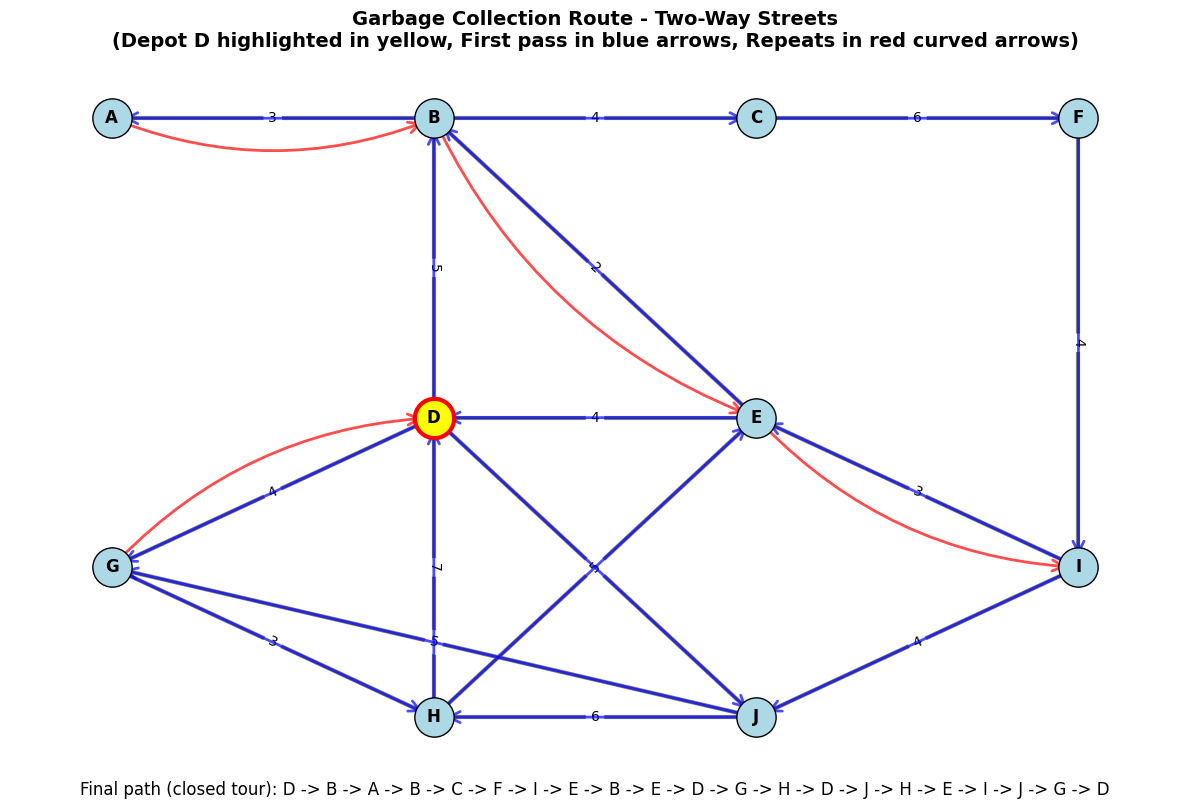

In [15]:
# Create an undirected graph
G = nx.Graph()

# Add edges with weights (travel times)
edges = [
  ('A', 'B', 3),
  ('B', 'C', 4),
  ('B', 'D', 5),
  ('B', 'E', 2),
  ('C', 'F', 6),
  ('D', 'E', 4),
  ('D', 'G', 4),
  ('D', 'H', 7),
  ('D', 'J', 5),
  ('E', 'H', 5),
  ('E', 'I', 3),
  ('F', 'I', 4),
  ('G', 'H', 3),
  ('G', 'J', 5),
  ('H', 'J', 6),
  ('I', 'J', 4)
]

for start, end, weight in edges:
    G.add_edge(start, end, weight=weight)

# Calculate positions for better layout
pos = {
  'A': (0, 3),
  'B': (2, 3),
  'C': (4, 3),
  'D': (2, 1),
  'E': (4, 1),
  'F': (6, 3),
  'G': (0, 0),
  'H': (2, -1),
  'I': (6, 0),
  'J': (4, -1)
}

# The solution path
# Solution 1
path = ['D', 'J', 'H', 'G', 'J', 'I', 'E', 'H', 'D', 'G', 'D', 'E', 'B', 'E', 'I', 'F', 'C', 'B', 'A', 'B', 'D']

# Solution 2
path = ['D', 'B', 'A', 'B', 'C', 'F', 'I', 'E', 'B', 'E', 'D', 'G', 'H', 'D', 'J', 'H', 'E', 'I', 'J', 'G', 'D']

path_edges = list(zip(path[:-1], path[1:]))

# Split path edges into first pass and repeats
first_pass_edges = []
repeat_edges = []
seen = set()
for u, v in path_edges:
    undir = frozenset({u, v})
    if undir not in seen:
        first_pass_edges.append((u, v))
        seen.add(undir)
    else:
        repeat_edges.append((u, v))

# Create the plot
plt.figure(figsize=(12, 8))

# Draw the graph
nx.draw_networkx_nodes(G, pos, node_size=800, node_color='lightblue', edgecolors='black')
nx.draw_networkx_edges(G, pos, edge_color='gray', width=3)
nx.draw_networkx_edge_labels(G, pos, edge_labels={(u, v): d['weight'] for u, v, d in G.edges(data=True)})
nx.draw_networkx_labels(G, pos, font_size=12, font_weight='bold')

# Highlight the depot (D)
nx.draw_networkx_nodes(G, pos, nodelist=['D'], node_size=800,
                      node_color='yellow', edgecolors='red', linewidths=3)

# Draw first pass path edges with straight blue arrows, alpha=0.7
nx.draw_networkx_edges(G, pos, edgelist=first_pass_edges, edge_color='blue', width=2, arrows=True, arrowstyle='->', arrowsize=20, alpha=0.7)

# Draw repeat path edges with curved red arrows, alpha=0.7
for u, v in repeat_edges:
  rad = 0.2 if u < v else -0.2  # Slight variation based on direction for visibility
  nx.draw_networkx_edges(G, pos, edgelist=[(u, v)], edge_color='red', width=2, arrows=True, arrowstyle='->', arrowsize=20, connectionstyle=f'arc3,rad={rad}', alpha=0.7)

plt.title("Garbage Collection Route - Two-Way Streets\n(Depot D highlighted in yellow, First pass in blue arrows, Repeats in red curved arrows)",
          fontsize=14, fontweight='bold')
plt.axis('off')
plt.tight_layout()

# Add the path as text below the plot
plt.figtext(0.5, 0, 'Final path (closed tour): ' + ' -> '.join(path), wrap=True, horizontalalignment='center', fontsize=12)

plt.show()